# SpaceX Falcon 9 — Exploratory Data Analysis (Visualization)

**Author:** Piyu

We explore relationships between flight number, payload mass, orbit type, launch site and landing success, using the wrangled dataset from Notebook 1.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df = pd.read_csv('../data/dataset_wrangled.csv')
df.head()

,FlightNumber,Date,Booster_Version,Launch_Site,Payload,PayloadMass,Orbit,Customer,Mission_Outcome,Landing _Outcome,Class
0,1,2010-04-06,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute),0
1,2,2010-08-12,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of...",0,LEO (ISS),NASA (COTS) NRO,Success,Failure (parachute),0
2,3,2012-05-22,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2,525,LEO (ISS),NASA (COTS),Success,No attempt,0
3,4,2012-08-10,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500,LEO (ISS),NASA (CRS),Success,No attempt,0
4,5,2013-01-03,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677,LEO (ISS),NASA (CRS),Success,No attempt,0


## 1. Flight Number vs. Launch Site

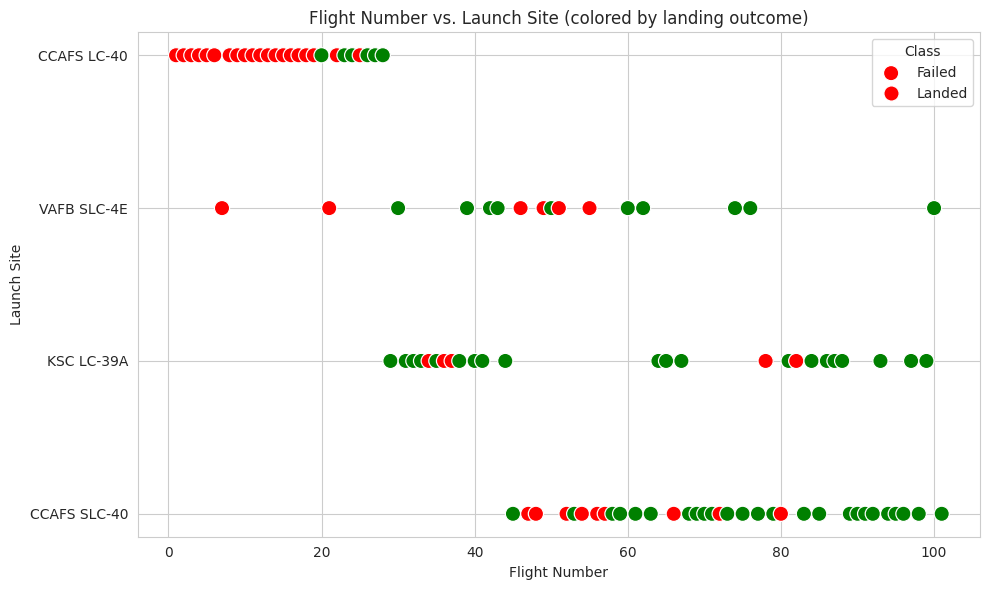

In [2]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='FlightNumber', y='Launch_Site', hue='Class', palette={0:'red',1:'green'}, s=120)
plt.title('Flight Number vs. Launch Site (colored by landing outcome)')
plt.xlabel('Flight Number')
plt.ylabel('Launch Site')
plt.legend(title='Class', labels=['Failed','Landed'])
plt.tight_layout()
plt.savefig('../images/flight_vs_site.png', dpi=120)
plt.show()

**Observation:** Later flights (higher flight number) cluster more toward successful landings (green), suggesting SpaceX's landing success rate improved with experience over time.

## 2. Payload Mass vs. Launch Site

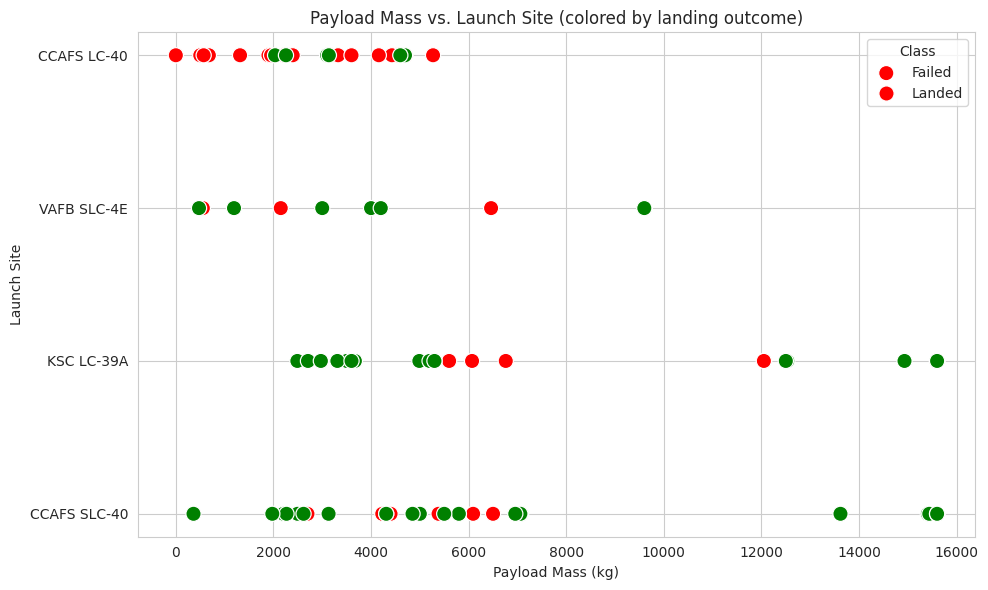

In [3]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='PayloadMass', y='Launch_Site', hue='Class', palette={0:'red',1:'green'}, s=120)
plt.title('Payload Mass vs. Launch Site (colored by landing outcome)')
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Launch Site')
plt.legend(title='Class', labels=['Failed','Landed'])
plt.tight_layout()
plt.savefig('../images/payload_vs_site.png', dpi=120)
plt.show()

## 3. Success Rate by Orbit Type

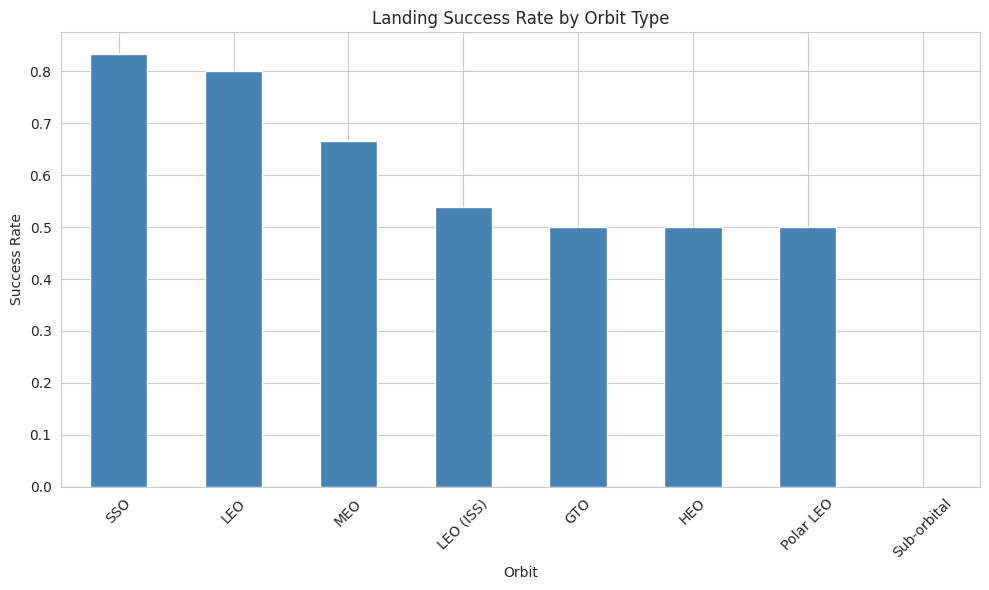

Orbit
SSO            0.833333
LEO            0.800000
MEO            0.666667
LEO (ISS)      0.538462
GTO            0.500000
HEO            0.500000
Polar LEO      0.500000
Sub-orbital    0.000000
Name: Class, dtype: float64

In [4]:
orbit_success = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
orbit_success.plot(kind='bar', color='steelblue')
plt.title('Landing Success Rate by Orbit Type')
plt.xlabel('Orbit')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/success_by_orbit.png', dpi=120)
plt.show()
orbit_success

## 4. Flight Number vs. Orbit Type

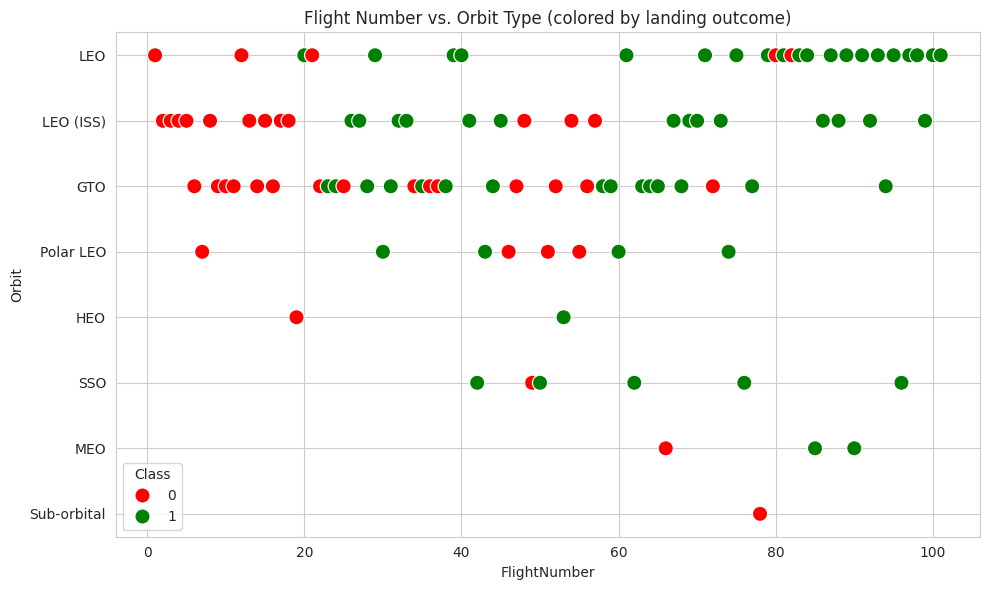

In [5]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='FlightNumber', y='Orbit', hue='Class', palette={0:'red',1:'green'}, s=120)
plt.title('Flight Number vs. Orbit Type (colored by landing outcome)')
plt.tight_layout()
plt.savefig('../images/flight_vs_orbit.png', dpi=120)
plt.show()

## 5. Payload Mass vs. Orbit Type

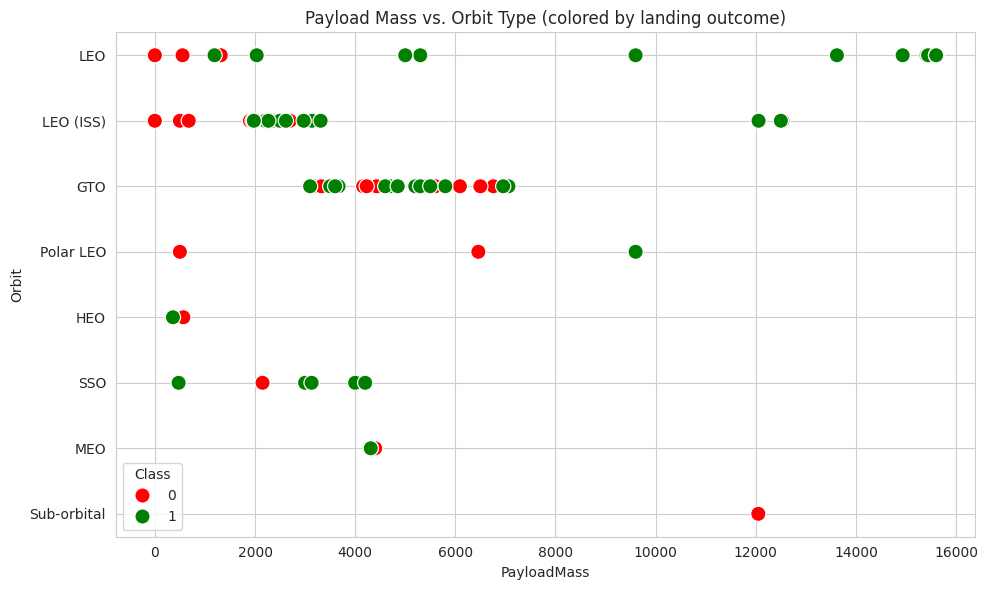

In [6]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='PayloadMass', y='Orbit', hue='Class', palette={0:'red',1:'green'}, s=120)
plt.title('Payload Mass vs. Orbit Type (colored by landing outcome)')
plt.tight_layout()
plt.savefig('../images/payload_vs_orbit.png', dpi=120)
plt.show()

## 6. Launch Success Yearly Trend

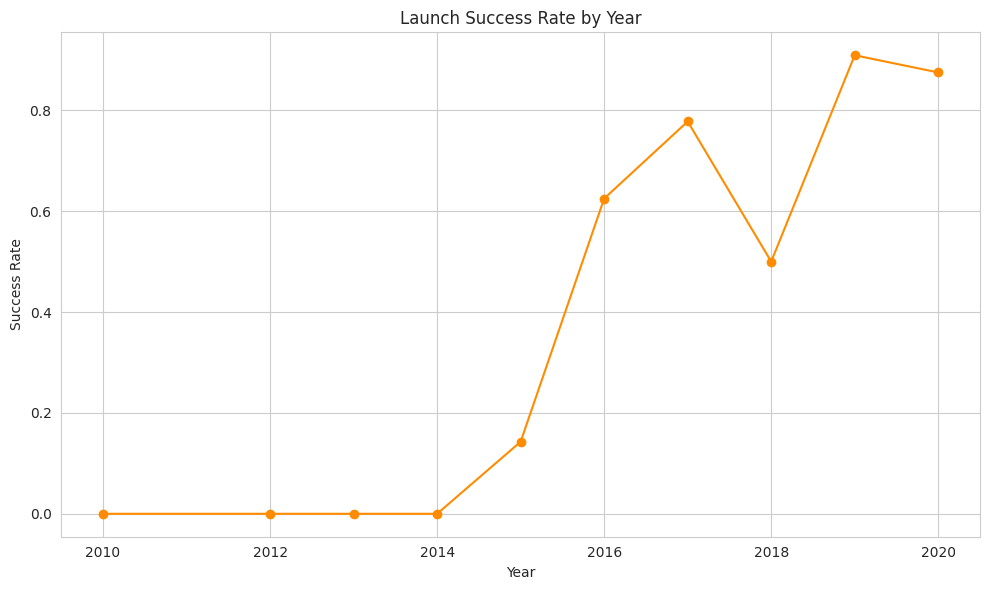

Year
2010    0.000000
2012    0.000000
2013    0.000000
2014    0.000000
2015    0.142857
2016    0.625000
2017    0.777778
2018    0.500000
2019    0.909091
2020    0.875000
Name: Class, dtype: float64

In [7]:
df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly_success = df.groupby('Year')['Class'].mean()

plt.figure(figsize=(10,6))
yearly_success.plot(kind='line', marker='o', color='darkorange')
plt.title('Launch Success Rate by Year')
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.tight_layout()
plt.savefig('../images/yearly_trend.png', dpi=120)
plt.show()
yearly_success

## Summary

- Success rate clearly trends upward with flight number — SpaceX got better at landing over time as the program matured
- Orbit type matters: some orbits (see bar chart output) show much higher landing success than others
- The yearly trend confirms steady improvement, consistent with SpaceX iterating on booster design and landing procedure
- These patterns (flight number, payload mass, orbit) become candidate features for the ML model in Notebook 6